In [2]:
# leggi il file missioni - 2025.xlsx in un dataframe 
# remove empty nan nat,.. lines

import pandas as pd

df = pd.read_excel("missioni - 2025.xlsx")
df = df.dropna(how='all')  # rimuove le righe completamente vuote
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 1 to 527
Data columns (total 6 columns):
 #   Column                                                                                  Non-Null Count  Dtype         
---  ------                                                                                  --------------  -----         
 0   DATA DI INIZIO MISSIONE                                                                 522 non-null    object        
 1   DATA DI RIENTRO                                                                         522 non-null    datetime64[ns]
 2   DATA CONSEGNA DOCUMENTAZIONE IN SEGRETERIA                                              522 non-null    object        
 3   DATA DI PRESA IN CARICO=CONTROLLO DOCUMENTAZIONE (EVENTUALE RICHIESTA INTEGRAZIONE)     522 non-null    datetime64[ns]
 4   DATA DI COMPLETAMENTO PRATICA (COMPLETA E VA IN CODA DA LIQUIDARE SE CON INTEGRAZIONI)  522 non-null    datetime64[ns]
 5   DATA EMISSIONE ORDINATIVO DI

In [3]:
# convert DATA DI INIZIO MISSIONE e DATA CONSEGNA DOCUMENTAZIONE IN SEGRETERIA  in datetime
df['DATA DI INIZIO MISSIONE'] = pd.to_datetime(df['DATA DI INIZIO MISSIONE'], errors='coerce')
df['DATA CONSEGNA DOCUMENTAZIONE IN SEGRETERIA'] = pd.to_datetime(df['DATA CONSEGNA DOCUMENTAZIONE IN SEGRETERIA'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 1 to 527
Data columns (total 6 columns):
 #   Column                                                                                  Non-Null Count  Dtype         
---  ------                                                                                  --------------  -----         
 0   DATA DI INIZIO MISSIONE                                                                 521 non-null    datetime64[ns]
 1   DATA DI RIENTRO                                                                         522 non-null    datetime64[ns]
 2   DATA CONSEGNA DOCUMENTAZIONE IN SEGRETERIA                                              522 non-null    datetime64[ns]
 3   DATA DI PRESA IN CARICO=CONTROLLO DOCUMENTAZIONE (EVENTUALE RICHIESTA INTEGRAZIONE)     522 non-null    datetime64[ns]
 4   DATA DI COMPLETAMENTO PRATICA (COMPLETA E VA IN CODA DA LIQUIDARE SE CON INTEGRAZIONI)  522 non-null    datetime64[ns]
 5   DATA EMISSIONE ORDINATIVO DI

Mean days: 51.73
Median days: 42.00


Text(0.5, 1.0, 'Distribution of Days between DATA DI RIENTRO and DATA EMISSIONE ORDINATIVO DI PAGAMENTO')

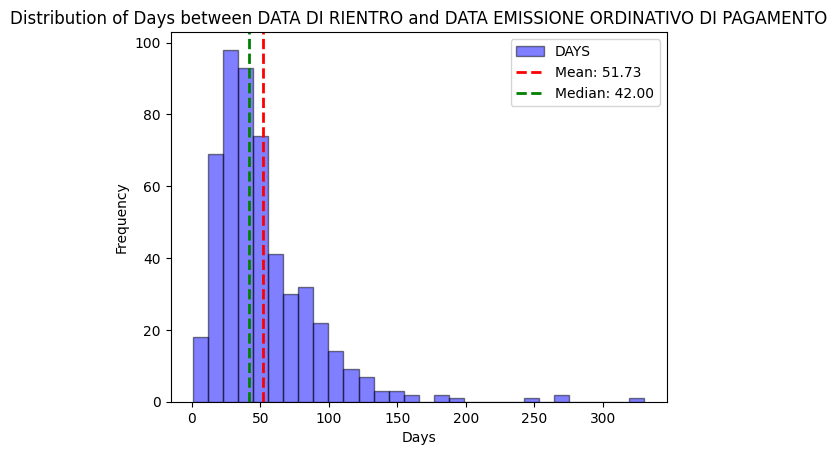

In [4]:
# add a column 'DAYS' with the number of days between 'DATA DI RIENTRO' and 'DATA EMISSIONE ORDINATIVO DI PAGAMENTO'"missioni - 2025.xlsx"

df['DAYS'] = (df['DATA EMISSIONE ORDINATIVO DI PAGAMENTO'] - df['DATA DI RIENTRO']).dt.days

df.head()

# compute the mean and median of the 'DAYS' column
mean_days = df['DAYS'].mean()
median_days = df['DAYS'].median()

print(f"Mean days: {mean_days:.2f}")
print(f"Median days: {median_days:.2f}")

# create a plot of the distribution of the 'DAYS' column using matplotlib. Add vertical lines for the mean and median, and add a legend.

plot = df['DAYS'].plot(kind='hist', bins=30, alpha=0.5, color='blue', edgecolor='black')
plot.axvline(mean_days, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_days:.2f}')
plot.axvline(median_days, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_days:.2f}')
plot.set_xlabel('Days') 
plot.set_ylabel('Frequency')
plot.legend()       
plot.set_title('Distribution of Days between DATA DI RIENTRO and DATA EMISSIONE ORDINATIVO DI PAGAMENTO')

